[![Open In Colab](https://raw.githubusercontent.com/crunchdao/competitions/refs/heads/master/documentation/badge/open-in-colab.svg)](https://colab.research.google.com/github/crunchdao/crunch-synth/blob/master/crunch_synth/examples/lightgbmtracker.ipynb)

![Banner](https://raw.githubusercontent.com/crunchdao/competitions/refs/heads/master/competitions/synth/assets/banner.webp)

# Synth Game

The goal is to anticipate how asset prices will evolve by providing not a single forecasted value, but a **full probability distribution over the future price change at multiple forecast horizons and steps.**

# Example Tracker: LightGBM Volatility Model

This notebook provides a **ML baseline tracker implementation** for the SYNTH challenge.

The workflow is:

1. Load historical asset price and exogenous data
2. Convert prices into returns
3. Extract statistical features from recent history
4. Train a LightGBM regression model to predict **future volatility**
5. Use the predicted volatility to generate a **probability distribution of future returns**
6. Run the tracker inside the evaluation framework

This notebook is intended as a **starting point**. You are encouraged to experiment with:

- Exogenous data
- Feature engineering
- Model parameters
- Forecast distribution assumptions
- Data preprocessing

The final predictions are evaluated using **CRPS** scoring.

## Setup

In [ ]:
# Install required dependencies
%pip install crunch_synth

In [ ]:
import numpy as np
import pandas as pd
import os
from tqdm.std import tqdm
from datetime import datetime, timezone, timedelta
import pickle
import warnings

## png render instead of plotly
# import plotly.io as pio
# pio.renderers.default = "png"  
# pio.renderers["png"].width = 1200
# pio.renderers["png"].height = 500

from crunch_synth import (
    TrackerBase,
    SubTracker,
    TrackerEvaluator,
    FORECAST_PROFILES,
    SUPPORTED_ASSETS,
    pricedb,
    PriceStore,
    Asset, 
    PriceData,
    load_test_prices_once,
    load_initial_price_histories_once,
    visualize_price_data,
    count_evaluations,
    plot_quarantine,
    plot_scores,
)

## Configurations

In [3]:
##########
# For each asset and historical timestamp, generate density forecasts
# over a fixed forecast horizon (e.g. 24h or 1h) at multiple temporal
# resolutions and evaluate them against realized outcomes.

# Select which forecast profile to evaluate
ACTIVE_HORIZON = "24h"  # options: "24h", "1h"

# Assets to evaluate
if ACTIVE_HORIZON == "24h":
    assets = ["BTC", "SOL", "ETH", "XAUT", "SPYX", "NVDAX", "TSLAX", "AAPLX", "GOOGLX"] # Supported assets: "BTC", "SOL", "ETH", "XAUT", "SPYX", "NVDAX", "TSLAX", "AAPLX", "GOOGLX"
else:
    assets = ["BTC", "SOL", "ETH", "XAUT"]  # Supported assets: "BTC", "SOL", "ETH", "XAUT"

# Filter (for backtesting)
assets = ["BTC"]

print("Supported assets:", ", ".join(SUPPORTED_ASSETS))
print("Selected assets:", ", ".join(assets))

HORIZON = FORECAST_PROFILES[ACTIVE_HORIZON]["horizon"]
STEPS = FORECAST_PROFILES[ACTIVE_HORIZON]["steps"]
INTERVAL = FORECAST_PROFILES[ACTIVE_HORIZON]["interval"]

# Base directory where all evaluation results will be stored
base_dir_results = "results"
os.makedirs(base_dir_results, exist_ok=True)

# End timestamp for the test data
# evaluation_end: datetime = datetime.now(timezone.utc)
evaluation_end: datetime = datetime(2026, 3, 11, 00, 00, 00, tzinfo=timezone.utc)

# Number of days of test data to load
# Note: the last `horizon` seconds of the time series will not be scored
days_test = 7

# Number of days of historical data used as warm-up before evaluation.
# This history is used only to initialize the tracker and is not scored.
days_history = 50

Supported assets: BTC, ETH, XAUT, SOL, SPYX, NVDAX, TSLAX, AAPLX, GOOGLX
Selected assets: BTC


## Data

In [4]:
## Load the last N days of price data (test period)
test_asset_prices = load_test_prices_once(
    assets, evaluation_end, days=days_test
)
# test_asset_prices : dict : {asset -> [(timestamp, price), ...]} used for evaluation.

## Train period
## Provide the tracker with initial historical data (for the first tick):
## load prices from the last H days up to N days ago
initial_histories = load_initial_price_histories_once(
    assets, evaluation_end, days_history=days_history, days_offset=days_test
)
# initial_histories : dict : {asset -> [(timestamp, price), ...]} used as warm-up history.

# Example: manually retrieving price history for an asset
# prices = pricedb.get_price_history(
#         asset="BTC",
#         from_=datetime(2024, 1, 1),
#         to=datetime(2024, 1, 3),
#     )

Dataset:


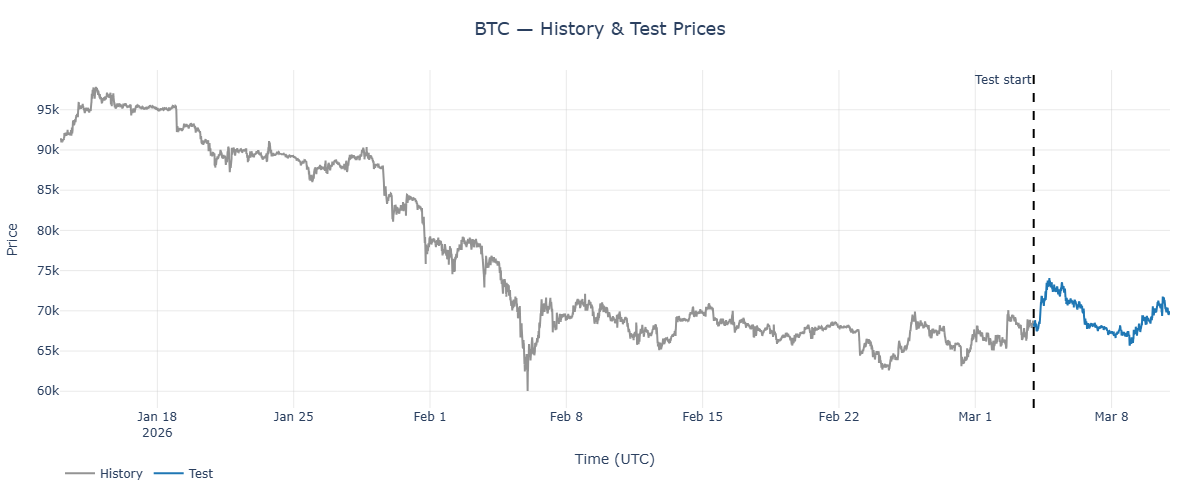

,asset,ts,price,split,time
0,BTC,1768262400,91193.822500,history,2026-01-13 00:00:00+00:00
1,BTC,1768262460,91243.935030,history,2026-01-13 00:01:00+00:00
2,BTC,1768262520,91246.852595,history,2026-01-13 00:02:00+00:00
3,BTC,1768262580,91273.500000,history,2026-01-13 00:03:00+00:00
4,BTC,1768262640,91271.000000,history,2026-01-13 00:04:00+00:00
...,...,...,...,...,...
82075,BTC,1773186900,69914.432669,test,2026-03-10 23:55:00+00:00
82076,BTC,1773186960,69903.191130,test,2026-03-10 23:56:00+00:00
82077,BTC,1773187020,69925.500000,test,2026-03-10 23:57:00+00:00
82078,BTC,1773187080,69923.795915,test,2026-03-10 23:58:00+00:00


In [5]:
visualize_price_data(
    history_data=initial_histories, test_data=test_asset_prices,
    selected_assets=None, show_graph=True
)

# Model training

In this section, the functions to train a model that predicts the **scale of future price movements** for each (horizon, asset).

Pipeline:

1. Convert price history into a time series dataframe
2. Extract statistical features from the recent window
3. Build a supervised dataset
4. Train a LightGBM model
5. Save the model for use inside the tracker

You can try new experiments with:
- feature engineering
- model type
- target definition

In [6]:
def compute_feat(past, timestamp, compute_time_feat=True):
    """
    Extract statistical features from a window of past returns.

    Features fall into three groups:

    1. Time context
    - hour of day
    - day of week

    2. Distribution statistics
    - mean, std, median, min, max
    - skewness and kurtosis

    3. Temporal / structural properties
    - linear trend (slope)
    - short-term and long-term volatility
    - lag-1 autocorrelation
    - energy and absolute variation

    Features are computed for the full lookback window.

    These features help the model detect patterns such as:
    - volatility clustering
    - intraday seasonal effects
    """

    def summary_features(x, is_constant, suffix=""):
        mean_ = np.mean(x)
        std_ = np.std(x)

        skew = ((x - mean_)**3).mean() / (std_**3 + 1e-9) if not is_constant else 0.0
        kurtosis = ((x - mean_)**4).mean() / (std_**4 + 1e-9) if not is_constant else 0.0

        values = [
            mean_,
            std_,
            np.median(x),
            np.min(x),
            np.max(x),
            skew,
            kurtosis,
            x[-1],
            x[0],
        ]

        names = [
            f"mean{suffix}",
            f"std{suffix}",
            f"median{suffix}",
            f"min{suffix}",
            f"max{suffix}",
            f"skew{suffix}",
            f"kurt{suffix}",
            f"last{suffix}",
            f"first{suffix}",
        ]

        return values, names

    def trend_features(x, is_constant, suffix=""):
        t = np.arange(len(x))
        slope = np.polyfit(t, x, 1)[0] if not is_constant else 0.0

        short_std = np.std(x[-25:])
        long_std = np.std(x[-100:])

        ac1 = np.corrcoef(x[:-1], x[1:])[0, 1] if len(x) > 1 and not is_constant else 0.0

        energy = np.sum(x**2)
        abs_sum = np.sum(np.abs(x))
        iqr = np.percentile(x, 90) - np.percentile(x, 10)

        values = [slope, short_std, long_std, ac1, energy, abs_sum, iqr]

        names = [
            f"slope{suffix}",
            f"short_std{suffix}",
            f"long_std{suffix}",
            f"ac1{suffix}",
            f"energy{suffix}",
            f"abs_sum{suffix}",
            f"iqr{suffix}",
        ]

        return values, names

    feats = []
    names = []

    # only constant values ?
    is_constant = np.allclose(past, past[0])

    # time features
    if compute_time_feat:
        feats += [
            timestamp.hour + timestamp.minute / 60,
            timestamp.weekday(),
        ]

        names += [
            "hour_of_day",
            "day_of_week",
        ]

    # full window
    v, n = summary_features(past, is_constant)
    feats += v
    names += n

    v, n = trend_features(past, is_constant)
    feats += v
    names += n

    return feats, names

In [7]:
def build_feature_dataframe(pairs_prices, dict_pairs_exogenous_series=None, resolution=300):
    """
    Build a dataframe with aligned prices for the main asset
    and all exogenous data stream.

    pairs -> (timestamp, value)
    """

    df = pd.DataFrame(pairs_prices, columns=["timestamp", "price"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")

    resolution_minute = int(resolution // 60)

    df = (
        df.resample(f"{resolution_minute}min", on="timestamp")
        .first()
        .reset_index()
        .sort_values("timestamp")
    )

    # merge each exogenous data stream using nearest backward direction
    if dict_pairs_exogenous_series is not None:
        for series_name, pairs_exogenous in dict_pairs_exogenous_series.items():

            df_exogenous = pd.DataFrame(
                pairs_exogenous, columns=["timestamp", f"value_{series_name}"]
            )

            df_exogenous["timestamp"] = pd.to_datetime(df_exogenous["timestamp"], unit="s")
            df_exogenous = df_exogenous.sort_values("timestamp")

            df = pd.merge_asof(
                df,
                df_exogenous,
                on="timestamp",
                direction="backward"
            )

    df = df.dropna()

    if len(df) == 0:
        raise ValueError("Empty dataset after alignment")

    return df


def build_training_data(pairs_prices, dict_pairs_exogenous_series=None, resolution=300, window_size=288, horizon_size=288):
    """
    Build supervised training dataset.

    pairs_prices: contains pairs of (timestamp, price)
    dict_pairs_exogenous_series: dict {asset:contains pairs of (timestamp, price)}
    resolution  : desired price sampling interval in seconds.
    window_size : number of past observations used as input
    horizon_size: number of future observations used for target

    For each timestamp t:

    Input features:
        statistical features computed from the previous `window_size` returns

    Target:
        the volatility (standard deviation) of returns over the next `horizon_size` steps

    Returns:
        X : feature matrix
        y : target volatility values
        feature_names : list of feature column names
    """

    df = build_feature_dataframe(pairs_prices, dict_pairs_exogenous_series, resolution)

    prices = df["price"].values
    timestamps = df["timestamp"].values

    returns = np.diff(prices)

    exogenous_returns = {
        col: np.diff(df[col].values)
        for col in df.columns if col.startswith("value_")
    }

    X = []
    y = []

    # Generate features and targets for each eligible timestamp
    for t in range(window_size, len(df) - horizon_size):

        feats, feature_names = compute_feat(
            returns[t-window_size:t],
            pd.Timestamp(timestamps[t])
        )

        # add exogenous features
        for col, r in exogenous_returns.items():

            feats_exogenous, feature_names_exogenous = compute_feat(
                r[t-window_size:t],
                pd.Timestamp(timestamps[t]),
                compute_time_feat=False
            )

            feats = np.concatenate([feats, feats_exogenous])
            feature_names = feature_names + [
                f"{col}_{n}" for n in feature_names_exogenous
            ]

        # Compute target volatility over future returns
        future_returns = returns[t:t+horizon_size]
        target = np.std(future_returns)

        X.append(feats)
        y.append(target)

    return np.array(X), np.array(y), feature_names

### Example: Build training data for a single asset

In [8]:
# pick the first asset for demonstration
print(f"Horizon: {HORIZON} Asset: {assets[0]}")

# histories[asset] contains tuples of (timestamp, price) at 1-minute resolution
pairs_prices = initial_histories[assets[0]]

# Build the feature matrix X and target vector y
X, y, feature_names = build_training_data(pairs_prices)

print("Feature matrix (X):")
display(pd.DataFrame(X, columns=feature_names).head())

print("Target vector (y) - future volatility:")
display(pd.DataFrame(y, columns=["target"]).head())

print(f"\nX shape: {X.shape}, y shape: {y.shape}")

Horizon: 86400 Asset: BTC
Feature matrix (X):


,hour_of_day,day_of_week,mean,std,median,min,max,skew,kurt,last,first,slope,short_std,long_std,ac1,energy,abs_sum,iqr
0,0.000000,2.0,14.661321,146.358798,10.430829,-494.386291,1717.027241,5.441409,65.348483,78.696994,80.384947,0.101213,372.426654,212.244038,-0.124830,6.231125e+06,23361.109947,237.567848
1,0.083333,2.0,14.159883,146.380150,9.120706,-494.386291,1717.027241,5.448451,65.385098,-64.029120,15.912553,0.100312,373.001317,212.408865,-0.125603,6.228763e+06,23344.754120,237.567848
2,0.166667,2.0,14.408081,146.443499,9.120706,-494.386291,1717.027241,5.436734,65.235377,87.393570,-64.112641,0.105718,373.009025,211.867593,-0.126455,6.236148e+06,23416.235137,237.567848
3,0.250000,2.0,14.916696,146.424276,10.430829,-494.386291,1717.027241,5.429337,65.194006,82.368455,7.831411,0.104917,155.635335,208.708554,-0.125707,6.238822e+06,23434.490951,237.567848
4,0.333333,2.0,14.863916,146.429559,10.430829,-494.386291,1717.027241,5.429819,65.192426,-7.369060,124.161229,0.102796,120.519706,206.999944,-0.125896,6.238815e+06,23434.028600,237.567848


Target vector (y) - future volatility:


,target
0,128.294068
1,128.467262
2,128.425623
3,128.539953
4,128.797816



X shape: (13824, 18), y shape: (13824,)


### What the model learns

The model predicts the **scale (volatility) of future returns**.

Steps:

1. Extract a window of past returns (~24h)
2. Compute statistical features
3. Look at the next 24h of returns
4. Train a model to predict the future volatility

The trained models are then used inside the **tracker** to generate probabilistic forecasts.

In [9]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

def train_model(horizon, asset, exogenous_series, histories, config, verbose=True):
    """
    Train a LightGBM model to predict the scale (volatility) of future returns.

    horizon : int
        Forecast horizon in seconds.
    asset : str
        Name of the asset being trained.
    exogenous_series : list[str]
        Name of the exogenous series being trained.
    histories : dict
        Dictionary containing historical price data for each asset and exogenous series.
    config : TrainingConfig
        Configuration object containing model, feature, and CV parameters.
    verbose : bool
        Whether to print training diagnostics.

    Returns
    model : LGBMRegressor
        Trained LightGBM model fitted on the full dataset.
    """

    print("\n*******************************************************")
    print(f"Training model for horizon {horizon}, asset {asset}")
    print("*******************************************************")

    # Ignore noisy warnings from dependencies
    warnings.filterwarnings("ignore", category=FutureWarning)

    # 1. Load historical price data
    # histories[asset] contains tuples of (timestamp, price)
    pairs_prices = histories[asset]
    dict_pairs_exogenous_series = {series_name: histories[series_name] for series_name in exogenous_series}

    # Convert forecast horizon into number of steps
    horizon_size = horizon // config.resolution
    
    # 2. Build supervised training dataset
    X, y, feature_names = build_training_data(pairs_prices, dict_pairs_exogenous_series, resolution=config.resolution, 
                                              window_size=config.window_size, horizon_size=horizon_size)

    print("Training samples:", X.shape)

    # 3. Time-series cross-validation
    # Cross-validation with early stopping
    kf = TimeSeriesSplit(n_splits=config.n_splits)
    scores = []
    all_importances = []

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X)):
        X_train, X_valid = X[train_idx], X[valid_idx]
        y_train, y_valid = y[train_idx], y[valid_idx]

        model = LGBMRegressor(**config.model_params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            eval_metric="mae",
            callbacks=[
                early_stopping(stopping_rounds=config.early_stopping_rounds, verbose=False),
                log_evaluation(period=0 if not verbose else 50),
            ],
        )

        y_pred = model.predict(X_valid)
        score = mean_absolute_error(y_valid.ravel(), y_pred)
        scores.append(score)
        if verbose:
            print(f"Fold {fold+1}/{config.n_splits} | MAE: {score:.6f}")

        # collect feature importances
        imp = pd.DataFrame({
            "feature": feature_names,
            "importance": model.feature_importances_,
            "fold": fold + 1
        })
        all_importances.append(imp)


    # Combine importances from all folds
    importances_df = (
        pd.concat(all_importances)
        .groupby("feature")["importance"]
        .agg(["mean", "std"])
        .sort_values("mean", ascending=False)
        .reset_index()
    )

    if verbose:
        print(f"Average MAE across folds: {np.mean(scores):.6f}")
        print("\nTop 10 features:")
        print(importances_df.head(10))

    # 4. Train final model on the full dataset
    # After validating hyperparameters with CV, we train
    # the final model using all available training data.
    model = LGBMRegressor(**config.model_params)
    model.fit(X, y)

    return model

In [10]:
from datetime import datetime
import requests


class APIPriceDbClient:
    """
    Generic client for retrieving external price time series (e.g. Pyth API).

    Provides access to exogenous data.

    Typical use cases include:
        - market indices (e.g. NASDAQ)
        - aggregated signals (e.g. GMCI30)
        - any auxiliary time series

    - Abstracts API-specific logic behind a simple interface
    - Supports historical data retrieval and latest price queries
    - Designed to be interchangeable with other data providers

    Backtesting:
        - data is typically preloaded for determinism
        - avoids repeated API calls

    Live:
        - fetches latest available values on demand
        - tolerant to missing or delayed data
    """

    # from https://docs.pyth.network/price-feeds/price-feeds
    _LATEST_PRICE_URL = "https://hermes.pyth.network/api/latest_price_feeds"
    _ASSET_TO_TOKEN_ID_MAP: dict = {
        "GMCI30":  "0xb3bd2a89c026fe7873da91b39bf9347fdea24e5b588330b4899788cf48878133",
        "NASDAQ":  "0x178a6f73a5aede9d0d682e86b0047c9f333ed0efe5c6537ca937565219c4054d",
        "SILVER":  "0xf2fb02c32b055c805e7238d628e5e9dadef274376114eb1f012337cabe93871e",
    }

    # from https://docs.pyth.network/price-feeds/price-feeds
    _HISTORY_URL = "https://benchmarks.pyth.network/v1/shims/tradingview/history"
    _ASSET_TO_SYMBOL_MAP: dict = {
        "GMCI30": "Crypto.Index.GMCI30/USD",
        "NASDAQ": "Crypto.QQQX/USD",
        "SILVER": "Metal.XAG/USD",
    }
    
    _HISTORY_RESOLUTION_MAPPING: dict[str, int | str] = {
        "minute": 1,
        "2minute": 2,
        "5minute": 5,
        "15minute": 15,
        "30minute": 30,
        "hour": 60,
        "2hour": 120,
        "4hour": 240,
        "6hour": 360,
        "12hour": 720,
        "day": "D",
        "week": "W",
        "month": "M",
    }

    def __init__(self):
        self._history_cache: dict[tuple, pd.Series] = {}

    def get_price_history(
        self,
        *,
        asset: str,
        from_: datetime,
        to: datetime,
        resolution: str = "minute",
        timeout=30,
    ) -> list[tuple[float, int]]:
        
        resolution_value = self._HISTORY_RESOLUTION_MAPPING.get(resolution)
        if resolution_value is None:
            raise ValueError(f"invalid resolution: {resolution}, only {self._HISTORY_RESOLUTION_MAPPING.keys()} are supported")
        
        cache_key = (asset, from_, to, resolution)
        cached = self._history_cache.get(cache_key)
        if cached is not None:
            print(f"using cached price history for {asset} from {from_} to {to} with resolution {resolution}")
            return cached.copy()

        query = {
            "symbol": self._ASSET_TO_SYMBOL_MAP[asset],
            "resolution": resolution_value,
            "from": self._unix_timestamp(from_),
            "to": self._unix_timestamp(to),
        }

        try:
            response = requests.get(
                self._HISTORY_URL,
                timeout=timeout,
                params=query,
            )

            response.raise_for_status()

            root = response.json()
            if root.get("s") != "ok":
                error_message = root.get("errmsg") or str(root)
                raise ValueError(f"api didn't returned ok: {error_message}")
        except Exception as error:
            raise ValueError(f"could not get price history for {asset}: {error}") from error
        
        if len(root["t"]):
            if len(self._history_cache) > 20:
                self.clear_cache()
            self._history_cache[cache_key] = list(zip(root["t"], root["c"]))

        return list(zip(root["t"], root["c"]))

    def get_price_history_chunked(
        self,
        *,
        asset: str,
        from_: datetime,
        to: datetime,
        resolution: str = "minute",
        chunk: timedelta = timedelta(days=2),
        timeout=30,
    ) -> list[tuple[int, float]]:
        
        all_prices: list[tuple[int, float]] = []
        current_start = from_

        while current_start < to:
            current_end = min(current_start + chunk, to)

            data = self.get_price_history(
                asset=asset,
                from_=current_start,
                to=current_end,
                resolution=resolution,
                timeout=timeout,
            )

            all_prices.extend(data)

            current_start = current_end

        return all_prices
    
    def get_last_price(
        self,
        *,
        asset: str,
        timeout=30,
    ) -> float:
        query = {
            "ids[]": self._ASSET_TO_TOKEN_ID_MAP[asset],
        }

        try:
            response = requests.get(
                self._LATEST_PRICE_URL,
                timeout=timeout,
                params=query,
            )

            response.raise_for_status()

            root = response.json()
            if len(root) != 1:
                raise ValueError(f"only one entry must be received: {root}")
        except Exception as error:
            raise ValueError(f"could not get last price for {asset}: {error}") from error

        entry = root[0]
        timestamp = int(entry["price"]["publish_time"])
        price = int(entry["price"]["price"])
        expo = int(entry["price"]["expo"])

        return (timestamp, price * (10**expo))

    def clear_cache(self):
        self._history_cache.clear()

    def clear_cache(self):
        self._history_cache.clear()

    def _unix_timestamp(self, object: datetime) -> int:
        object = object.replace(tzinfo=timezone.utc)

        return int(object.timestamp())

## SubTracker: Specialized Forecasting Unit

A `SubTracker` is responsible for **modeling a subset of (asset, horizon) pairs**.

Each SubTracker encapsulates:
- its own data pipeline (features, preprocessing)
- its own model(s)
- its own training lifecycle

For the **full list of supported (horizon, asset) combinations**, refer to the documentation: https://docs.crunchdao.com/real-time-competitions/competitions/synth#prediction-phase.

**Model Design:**

- Features:
    - statistical features on past returns
    - time-based features (hour, weekday, etc.)
    - optional exogenous signals

- Target:
    - future realized volatility proxy

- Output:
    - Gaussian distributions per forecast step

- Models are trained periodically using a rolling window
- One model per (asset, horizon)
- Retraining is triggered:
    - automatically (scheduler)
    - or on first tick if not fitted

- External time series are used as additional features.

In [ ]:
class MySubTracker(SubTracker):
    """
    SubTracker that trains a model in background via cron (Online retraining: model can retrain periodically as new data arrives)

    A LightGBM based forecasting tracker that models *future incremental returns* as Gaussian-distributed.

    For each forecast step, the tracker returns a normal distribution
    r_{t,step} ~ N(a · mu, √a · sigma) where:
        - mu    = mean historical return
        - sigma = std historical return
        - a = (step / resolution) represents the ratio of the forecast step duration to the historical resolution return interval.

    Multi-resolution forecasts (5min, 1h, 6h, 24h, ...)
    are automatically handled by `TrackerBase.predict_all()`,
    which calls the `predict()` method once per step size.

    /!/ This is not a price-distribution; it is a distribution over
    incremental returns between consecutive steps /!/
    """

    def __init__(
        self,
        config,
        end_date_training=None,             # default value in live mode
        filter_assets=SUPPORTED_ASSETS,     # default value in live mode
        specific_horizon=None,              # default value in live mode
        exogenous_db=None                   # default value in live mode
    ):
        """
        Initialize the tracker.

        Parameters
        ----------
        config : object
            Configuration object containing model and data parameters.
        end_date_training : datetime, optional
            If provided, enables backtest mode and fixes the training cutoff date.
        filter_assets : list, optional
            Subset of supported assets to use (useful for local testing).
        specific_horizon : int, optional
            Restrict training to a single horizon (for debugging/backtesting).
        exogenous_db : object, optional
            External data source for exogenous signals (for debugging/backtesting).
        """

        self.config = config

        self.fitted = False
        self.scales = {}

        # Filter assets handled by this SubTracker (allow to use specific assets during local backtesting)
        self.tracker_assets = [asset for asset in self.config.assets if asset in filter_assets]

        # Define training cutoff
        self.end_date_training = end_date_training if end_date_training is not None else datetime.now(tz=timezone.utc)

        # Backtest mode is enabled when a fixed end_date_training is provided
        self.is_backtest = True if end_date_training is not None else False

        # allow to use a specific horizon during local backtesting
        self.specific_horizon = specific_horizon

        # External data source for exogenous signals
        # (pre-initialized in backtest for determinism)
        self.exogenous_pricedb = exogenous_db or APIPriceDbClient()  # (backtest or live mode)

        # Initialize price storage
        self.data_initialization()

        # Warm-start: in live mode, load any pre-existing models from the 'resources/' directory.
        if not self.is_backtest:
            # This allows predictions to continue while first training loop isn't finished.
            # Also enables recovery of previously trained models if the online system stops unexpectedly.
            self._load_existing_models()

    def data_initialization(self):
        """
        Initialize the local price store with historical data.

        Loads:
        - Asset price histories
        - Exogenous time series (treated like assets)

        Notes
        -----
        - In live environments, only limited history may be available initially,
          so this method ensures sufficient backfill.
        """
        if len(self.tracker_assets) > 0:
            print("\n-----------------------------------------------------")
            print(f"Init {self.config.name} tracker")
            print("-----------------------------------------------------")

        # To store prices of provided asset prices by CRUNCH and exogenous dataset stream
        self.prices = PriceStore(window_days=self.config.window_days)

        from_ = self.end_date_training - timedelta(days=self.config.window_days)
        to = self.end_date_training

        # On the platform, only the last 30 days of asset prices will be provided in the first tick
        # If you need more, init yourself the PriceStore:
        initial_histories = {}
        for asset in self.tracker_assets:
            print(f"Init asset {asset} with {self.config.window_days} days of prices from {from_} to {to}...")
            initial_histories[asset] = pricedb.get_price_history(
                asset=asset,
                from_=from_,
                to=to,
            )

        # Load exogenous time series
        # These are treated exactly like assets in the feature pipeline
        if len(self.tracker_assets) > 0:
            for series_name in self.config.exogenous_series:
                print(f"Init asset {series_name} with {self.config.window_days} days of prices from {from_} to {to}...")
                initial_histories[series_name] = self.exogenous_pricedb.get_price_history_chunked(
                    asset=series_name,
                    from_=from_,
                    to=to,
                    resolution="5minute",
                    chunk=timedelta(days=10)
                )

        self.prices.add_bulk(initial_histories)

    def tick(self, data: PriceData):
        """
        Update the tracker with new incoming data.

        Parameters
        ----------
        data : PriceData
            New batch of price updates.
            data = {
                "BTC": [(ts1, p1), (ts2, p2)],
                "SOL": [(ts1, p1)],
            }

        Behavior
        --------
        - Updates local price store
        - Fetch the latest exogenous values yourself in live mode
        """
        # Ingest new data into the local price store
        self.prices.add_bulk(data)

        # Update exogenous signals:
        # - backtest -> already preloaded
        # - live -> fetch latest value from API if missing
        for series_name in self.config.exogenous_series:

            # if we are not in backtesting mode, we need to get last point from API
            if series_name not in data and not self.is_backtest:
                try:
                    last_price = self.exogenous_pricedb.get_last_price(asset=series_name)
                    self.prices.add_bulk({series_name: [last_price]})
                except:
                    pass

    def _model_path(self, horizon: int, asset: str) -> str:
        """Return path for a given (horizon, asset) model."""
        os.makedirs("resources", exist_ok=True) # On CrunchDAO platform, you can store files into the directory named "resources/"
        return f"resources/model_{horizon}_{asset}.pkl"

    def _save_model(self, model, horizon: int, asset: str):
        """Persist model to disk."""
        path = self._model_path(horizon, asset)
        with open(path, "wb") as f:
            pickle.dump(model, f)

    def _load_model(self, horizon: int, asset: str):
        """Load model from disk if it exists."""
        path = self._model_path(horizon, asset)
        if os.path.exists(path):
            try:
                with open(path, "rb") as f:
                    return pickle.load(f)
            except Exception as e:
                print(f"[Model Load Warning] Failed to load {path}: {e}")
        return None
    
    def _load_existing_models(self):
        """
        Load all available models from disk.

        This enables warm-start:
        - skip initial training if models already exist
        """
        self.models = {}

        # loop per horizon
        for horizon in self.config.horizons:
            self.models[horizon] = {}

            for asset in self.tracker_assets:
                model = self._load_model(horizon, asset)
                if model is not None:
                    print(f"[{self.config.name}] Horizon [{horizon}] Asset [{asset}] Loaded existing models from 'resources/'")
                    self.models[horizon][asset] = model

    def train(self):
        """
        Train one model per (horizon, asset)
        Models are stored as `self.models[horizon][asset]`
        """
        if len(self.tracker_assets) == 0:
            return

        new_models = {horizon: {} for horizon in self.config.horizons}  # get all supported horizon

        # Use rolling window data for both primary and exogenous series
        initial_histories = {asset: self.prices.get_prices(asset, days=self.config.window_days) for asset in self.tracker_assets}
        for series_name in self.config.exogenous_series:
            initial_histories[series_name] = self.prices.get_prices(series_name, days=self.config.window_days)

        for horizon in new_models.keys():
            if self.specific_horizon and horizon != self.specific_horizon:
                continue
            print("\n-----------------------------------------------------")
            print(f"Training {self.config.name} tracker for horizon {horizon}")
            print("-----------------------------------------------------")

            # for asset in tqdm(self.tracker_assets):
            for asset in self.tracker_assets:
                try:
                    model = train_model(horizon, asset, self.config.exogenous_series, initial_histories, self.config)

                    new_models[horizon][asset] = model
                    # Save
                    self._save_model(model, horizon, asset)
                except Exception as e:
                    print(f"Error: {e}")
                    # If training fails, fallback to previous model (if available)
                    if hasattr(self, 'models'):
                        new_models[horizon][asset] = self.models[horizon][asset]

        self.models = new_models
        self.fitted = True

    def predict(self, asset: str, horizon: int, step: int):
        """ Generate probabilistic forecasts for a given asset and horizon """
        try:
            # Build feature vector from:
            # - recent asset returns
            # - aligned exogenous returns

            # Retrieve recent historical prices
            pairs = self.prices.get_prices(asset, days=self.config.required_history_days())

            dict_pairs_exogenous_series = {
                series_name: self.prices.get_prices(
                    series_name, days=self.config.required_history_days()
                )
                for series_name in self.config.exogenous_series
            }

            if not pairs:
                return []

            df = build_feature_dataframe(pairs, dict_pairs_exogenous_series, self.config.resolution)

            prices = df["price"].values
            timestamps = df["timestamp"].values

            returns = np.diff(prices)

            past = returns[-self.config.window_size:]
            current_time = pd.Timestamp(timestamps[-1])

            feats, feature_names = compute_feat(past, current_time)

            # add exogenous features
            for col in df.columns:
                if col.startswith("value_"):
                    r = np.diff(df[col].values)

                    feats_exogenous, feature_names_exogenous = compute_feat(
                        r[-self.config.window_size:],
                        current_time,
                        compute_time_feat=False
                    )

                    feats = np.concatenate([feats, feats_exogenous])
                    feature_names = feature_names + [
                        f"{col}_{n}" for n in feature_names_exogenous
                    ]

            X = pd.DataFrame([feats], columns=feature_names)

            if asset not in self.models[horizon]:
                raise ValueError(f"Missing model horizon {horizon}, asset {asset}")

            # Predict volatility scale using trained model
            scale = float(self.models[horizon][asset].predict(X)[0])

            self.scales[asset] = scale

        except Exception as e:
            # In case of an error, predict scale from historical volatility
            if "Missing model" in str(e):
                print(
                    f"[Warning] Model missing for asset={asset}, horizon={horizon}. "
                    f"Training may still be in progress; you can use pre-loaded models. "
                    f"Falling back to historical volatility. Details: {e}"
                )
            else:
                print(
                    f"[Tracker Warning] Feature computation or model prediction failed "
                    f"for asset={asset}, horizon={horizon}. "
                    f"Falling back to historical volatility. Details: {e}"
                )

            # Retrieve recent historical prices (up to 30 days)
            pairs = self.prices.get_prices(asset, days=10, resolution=300)
            _, past_prices = zip(*pairs)

            # Compute historical incremental returns (price differences)
            returns = np.diff(past_prices)

            # Estimate volatility (std dev of returns)
            scale = float(np.std(returns))

        num_segments = horizon // step

        # Convert predicted scale into step-wise Gaussian distributions
        # using Brownian scaling: σ_step = √(step / resolution) × scale
        distributions = []
        for k in range(1, num_segments + 1):
            distributions.append({
                "step": k * step,  # Time offset (in seconds) from forecast origin
                "type": "mixture",
                "components": [{
                    "density": {
                        "type": "builtin",  # Note: use 'builtin' distributions instead of 'scipy' for speed
                        "name": "norm",
                        "params": {
                            "loc": 0.0,  # Assume zero drift
                            "scale": np.sqrt(step / self.config.resolution) * scale
                        }
                    },
                    "weight": 1  # Mixture weight — multiple densities with different weights can be combined
                    # total components capped for runtime safety to constants.MAX_DISTRIBUTION_COMPONENTS
                }]
            })

        return distributions

## Main Tracker: Multi-Horizon and Multi-Asset  Orchestrator

This tracker acts as a **routing and orchestration layer** over multiple specialized `SubTracker` instances.

Each `SubTracker` is responsible for:
- a specific asset class (e.g: crypto, equities, metals)
- its own feature engineering and model training

In [12]:
class LightGBMVolatilityTracker(TrackerBase):

    def __init__(self, end_date_training=None, filter_assets=SUPPORTED_ASSETS, specific_horizon=None, exogenous_db=None):
        # Determine execution mode based on whether a training end date is provided:
        # - Backtest mode: a fixed `end_date_training` is given -> synchronous, deterministic execution
        # - Live mode: no end date provided -> use current time and enable asynchronous processing
        async_mode = True if end_date_training is None else False
        data_clock = datetime.now(tz=timezone.utc) if end_date_training is None else end_date_training
        super().__init__(data_clock=data_clock, async_mode=async_mode)

        # SubTrackers Initialization
        # Each SubTracker handles a specific asset class
        self.crypto_tracker = MySubTracker(Constants.CRYPTO_CONFIG, end_date_training, filter_assets, specific_horizon, exogenous_db)
        self.stock_tracker = MySubTracker(Constants.STOCK_CONFIG, end_date_training, filter_assets, specific_horizon, exogenous_db)
        self.metal_tracker = MySubTracker(Constants.METAL_CONFIG, end_date_training, filter_assets, specific_horizon, exogenous_db)

        # Route predictions to the sub-tracker
        # Map (horizon, asset) -> SubTracker
        # Enables flexible multi-horizon and multi-asset routing
        HOUR = 3600
        self.track(24 * HOUR, self.crypto_tracker.tracker_assets, self.crypto_tracker)
        self.track(1 * HOUR, self.crypto_tracker.tracker_assets, self.crypto_tracker)

        self.track(24 * HOUR, self.stock_tracker.tracker_assets, self.stock_tracker)
        # No stock assets prediction needed for 1H Horizon

        self.track(24 * HOUR, self.metal_tracker.tracker_assets, self.metal_tracker)
        self.track(1 * HOUR, self.metal_tracker.tracker_assets, self.metal_tracker)

        # Scheduling (Periodic Retraining)
        # Retrain each SubTracker periodically.
        # Slight offsets prevent all models from retraining simultaneously.
        self.schedule('Crypto train', self.crypto_tracker.train, timedelta(days=5), immediate=True) # immediate=True means train at initialization
        self.schedule('Stock train', self.stock_tracker.train, timedelta(days=5.1), immediate=True)
        self.schedule('Metal train', self.metal_tracker.train, timedelta(days=5.2), immediate=True)
        # The frequency time is the same between 24H and 1H Horizon, but you can changed it

        # ------------------------------------------------------------
        # Backtesting vs Live Mode
        # ------------------------------------------------------------
        # Online retraining: model can retrain periodically as new data arrives
        #
        # - Backtesting:
        #     - deterministic
        #     - no threads
        #     - training triggered inside tick()
        # - Live:
        #     - background training (async mode)
        #     - event-driven updates

### Initialize exogenous data stream and preload their test stream for backtesting

In [13]:
# Fetch your own exogenous historical time series data
exogenous_db = APIPriceDbClient()

# External time series used as additional context features during training/inference.
# You don't need necessarily to use tradable assets:
# - "GMCI30": index representing top 30 cryptocurrencies
# - "NASDAQ": equity market index
exogenous_series = ["GMCI30", "NASDAQ"]

# Training ends where evaluation begins
end_date_training = evaluation_end - timedelta(days=days_test)

# Time window used for backtesting
from_ = end_date_training
to = evaluation_end

# ============================================================
# Preloading Data for Backtesting
# ============================================================

# During backtesting, we replay data sequentially ("tick by tick").
# To ensure deterministic behavior and avoid repeated API calls,
# we preload all required time series into memory.

# Format:
# {
#     "GMCI30": [(timestamp, value), ...],
#     "NASDAQ": [(timestamp, value), ...],
# }
#
# Each series is sorted by timestamp and will be aligned
# with the main asset stream during simulation.
exogenous_future_ticks = {}

for series_name in exogenous_series:
    print(
        f"Test set: Load context series '{series_name}' "
        f"({days_test} days) from {from_} to {to}..."
    )

    # Load historical data in chunks to avoid large API calls and memory spikes.
    # Data will later be replayed synchronously with the main asset stream.
    exogenous_future_ticks[series_name] = exogenous_db.get_price_history_chunked(
        asset=series_name,
        from_=from_,
        to=to,
        resolution="5minute",
        chunk=timedelta(days=10),
    )

Test set: Load context series 'GMCI30' (7 days) from 2026-03-04 00:00:00+00:00 to 2026-03-11 00:00:00+00:00...
Test set: Load context series 'NASDAQ' (7 days) from 2026-03-04 00:00:00+00:00 to 2026-03-11 00:00:00+00:00...


## SubTracker configuration

For the **full list of supported (horizon, asset) combinations**, refer to the documentation: https://docs.crunchdao.com/real-time-competitions/competitions/synth#prediction-phase.

In [14]:
## Configurations
# It defines the main parameters used throughout the training.
from dataclasses import dataclass

@dataclass
class TrainingConfig:
    name: str
    assets: list                     # which assets are modeled
    horizons: list                   # which horizons are modeled
    exogenous_series: list           # which external signals are used

    # Data / feature parameters
    window_days: int
    resolution: int   # in seconds
    window_size: int  # in number of points

    # CV parameters
    n_splits: int
    early_stopping_rounds: int

    # LightGBM parameters
    model_params: dict

    def required_history_days(self) -> int:
        return int(self.window_size * self.resolution / 86400) + 1


class Constants:

    CRYPTO_CONFIG = TrainingConfig(
        name="crypto",
        assets=["BTC", "SOL", "ETH"],
        horizons=[86400, 3600],
        exogenous_series=["GMCI30"],

        window_days=50,
        resolution=300,
        window_size=288,

        n_splits=5,
        early_stopping_rounds=100,

        model_params={
            "objective": "regression",
            "learning_rate": 0.05,
            "n_estimators": 300,
            "max_depth": 6,
            "num_leaves": 20,
            "reg_alpha": 0.1,
            "reg_lambda": 0.3,
            "min_child_samples": 20,
            "random_state": 42,
            "verbose": -1
        }
    )

    STOCK_CONFIG = TrainingConfig(
        name="stock",
        assets=["SPYX", "NVDAX", "TSLAX", "AAPLX", "GOOGLX"],
        horizons=[86400],
        exogenous_series=["NASDAQ"],

        window_days=50,
        resolution=300,
        window_size=288,

        n_splits=5,
        early_stopping_rounds=100,
        model_params={
            "objective": "regression",
            "learning_rate": 0.05,
            "n_estimators": 300,
            "max_depth": 6,
            "num_leaves": 20,
            "reg_alpha": 0.1,
            "reg_lambda": 0.3,
            "min_child_samples": 20,
            "random_state": 42,
            "verbose": -1
        }
    )

    METAL_CONFIG = TrainingConfig(
        name="metal",
        assets=["XAUT"],
        horizons=[86400, 3600],
        exogenous_series=["GMCI30", "NASDAQ"],
        
        window_days=50,
        resolution=300,
        window_size=288,
        
        n_splits=5,
        early_stopping_rounds=100,
        model_params={
            "objective": "regression",
            "learning_rate": 0.05,
            "n_estimators": 600,
            "max_depth": 3,
            "num_leaves": 20,
            "reg_alpha": 0.1,
            "reg_lambda": 0.3,
            "min_child_samples": 20,
            "random_state": 42,
            "verbose": -1
        }
    )

## Backtest Simulation: Run live simulation on historic TEST data

Before submitting a tracker, it is useful to simulate its behavior on historical data.

Replay the historical test price stream, at each timestamp `t` in Test set:

1. New data arrives -> `tick()`
2. Models may retrain (scheduled) -> `train()`
3. Predictions are generated -> `predict()`
4. Predictions are evaluated only at `t + horizon` using CRPS

It operate in a **time-series streaming setting**, where data is revealed sequentially. Two types of inputs are used:

1. Primary assets: Assets for which predictions are generated (e.g. BTC) provided by `pricedb` from crunch_synth
2. Exogenous series: Auxiliary signals that provide potential context (e.g. indices, macro signals; NASDAQ, GMCI 30) provided by a custom API


-----------------------------------------------------
Init crypto tracker
-----------------------------------------------------
Init asset BTC with 50 days of prices from 2026-01-13 00:00:00+00:00 to 2026-03-04 00:00:00+00:00...
Init asset GMCI30 with 50 days of prices from 2026-01-13 00:00:00+00:00 to 2026-03-04 00:00:00+00:00...

-----------------------------------------------------
Training crypto tracker for horizon 86400
-----------------------------------------------------

*******************************************************
Training model for horizon 86400, asset BTC
*******************************************************
Training samples: (13824, 34)
[50]	valid_0's l1: 22.2472	valid_0's l2: 645.071
[100]	valid_0's l1: 23.2017	valid_0's l2: 688.019
Fold 1/5 | MAE: 18.929120
[50]	valid_0's l1: 91.6987	valid_0's l2: 9856.59
[100]	valid_0's l1: 92.0869	valid_0's l2: 9919.81
[150]	valid_0's l1: 91.7835	valid_0's l2: 9857.36
Fold 2/5 | MAE: 91.441672
[50]	valid_0's l1: 48.6293	v

Evaluating all assets:  12%|█▎        | 18/144 [00:06<00:28,  4.43eval/s]

[BTC] avg norm CRPS=23.5290 | recent=23.5290


Evaluating all assets:  26%|██▌       | 37/144 [00:10<00:24,  4.45eval/s]

[BTC] avg norm CRPS=21.5069 | recent=21.5069


...

[BTC] avg norm CRPS=16.7490 | recent=15.5963


Evaluating all assets:  95%|█████████▌| 137/144 [00:45<00:01,  4.16eval/s]

[BTC] avg norm CRPS=17.1682 | recent=15.5630


Evaluating all assets: 100%|██████████| 144/144 [00:47<00:00,  3.02eval/s]




Tracker LightGBMVolatilityTracker:
Final average normalized CRPS score: 17.3773
[✔] Tracker results saved to results\2026-03-05T00-00-00_to_2026-03-10T23-00-00\LightGBMVolatilityTracker_h86400.json

(Note - Scores appear after quarantine: a score at time t evaluates a forecast issued at (t - horizon))


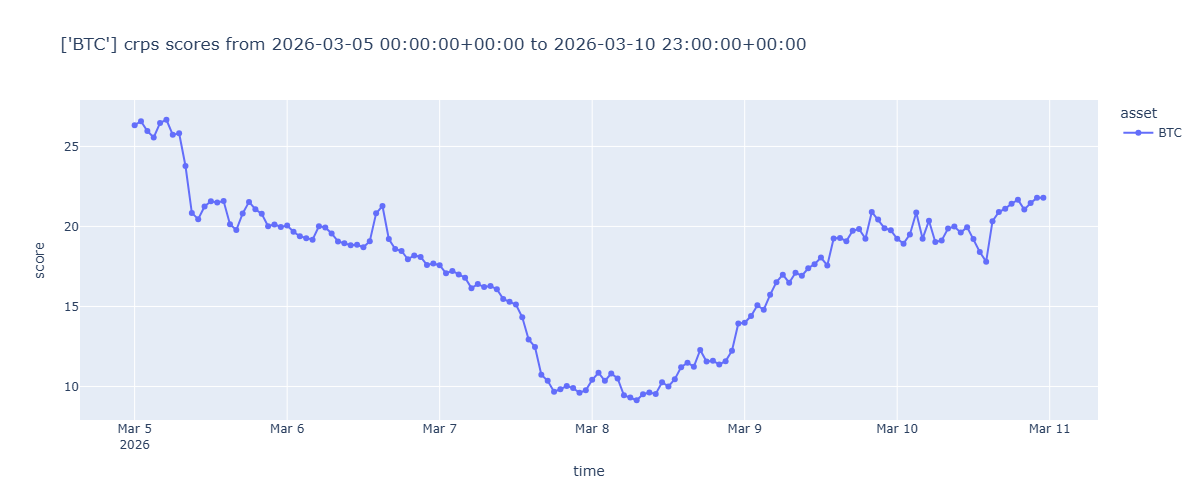

In [15]:
# Setup tracker
tracker = LightGBMVolatilityTracker(
    end_date_training=evaluation_end - timedelta(days=days_test),  # specific to backtesting
    filter_assets=assets,                                          # specific to backtesting
    specific_horizon=HORIZON,                                      # specific to backtesting
    exogenous_db=exogenous_db                                      # specific to backtesting
)

# Setup evaluator
tracker_evaluator = TrackerEvaluator(tracker)

# Initialize all assets with historical data
tracker_evaluator.tick(initial_histories)  # feed full history before test period

# Prepare tqdm
total_ticks = max(count_evaluations(prices, HORIZON, INTERVAL) for prices in test_asset_prices.values())
pbar = tqdm(desc="Evaluating all assets", total=total_ticks, unit="eval")

# Keep track of last prediction timestamps for interval logic
prev_ts = {asset: 0 for asset in assets}
predict_count = {asset: 0 for asset in assets}

# Keep track of exogenous indices for all series
exogenous_indices = {series_name: 0 for series_name in exogenous_series}

# Merge all timestamps across assets into a sorted list
all_timestamps = sorted({ts for prices in test_asset_prices.values() for ts, _ in prices})

# Main loop: iterate over timestamps
for ts in all_timestamps:
    tick_data = {}

    # Collect latest price for each asset at this timestamp
    for asset in assets:
        # Find if there is a price at this timestamp
        asset_prices = test_asset_prices[asset]
        # Get price(s) matching current ts
        price_ticks = [price for t, price in asset_prices if t == ts]
        if price_ticks:
            tick_data[asset] = [(ts, price_ticks[-1])]  # use last tick if multiple

    # Collect exogenous data for this timestamp
    for series_name in exogenous_series:
        series = exogenous_future_ticks[series_name]
        i = exogenous_indices[series_name]
        # Move pointer forward while next timestamp <= ts
        while i + 1 < len(series) and series[i + 1][0] <= ts:
            i += 1
        exogenous_indices[series_name] = i
        if i < len(series) and series[i][0] <= ts:
            tick_data.setdefault(series_name, []).append(series[i])

    # Feed the new tick for all assets
    tracker_evaluator.tick(tick_data)

    # Trigger prediction per asset at the configured interval
    lines_to_write = []
    any_prediction = False  # track if at least one asset predicted this tick

    for asset in assets:
        if ts - prev_ts[asset] >= INTERVAL:
            prev_ts[asset] = ts
            predictions_evaluated = tracker_evaluator.predict(asset, HORIZON, STEPS)

            if predictions_evaluated:
                any_prediction = True  # mark that we should update the bar

            # Accumulate lines for assets that should display now
            if predictions_evaluated and predict_count[asset] % 20 == 0:
                lines_to_write.append(
                    f"[{asset}] avg norm CRPS={tracker_evaluator.overall_score_asset(asset):.4f} | "
                    f"recent={tracker_evaluator.recent_score_asset(asset):.4f}"
                )
            predict_count[asset] += 1

    # Update progress bar once per timestamp if any asset predicted
    if any_prediction:
        pbar.update(1)

    # Write all accumulated lines at once
    if lines_to_write:
        pbar.write("\n".join(lines_to_write))

pbar.close()
print()

# Global summary across all assets
tracker_name = tracker_evaluator.tracker.__class__.__name__
print(f"\nTracker {tracker_name}:"
      f"\nFinal average normalized CRPS score: {tracker_evaluator.overall_score():.4f}")

# Persist results
current_results_dir = tracker_evaluator.to_json(
    horizon=HORIZON, steps=STEPS, interval=INTERVAL, base_dir=base_dir_results
)

# Plot scoring timeline
timestamped_scores = tracker_evaluator.scores
print("\n(Note - Scores appear after quarantine: a score at time t evaluates a forecast issued at (t - horizon))")
plot_scores(timestamped_scores)

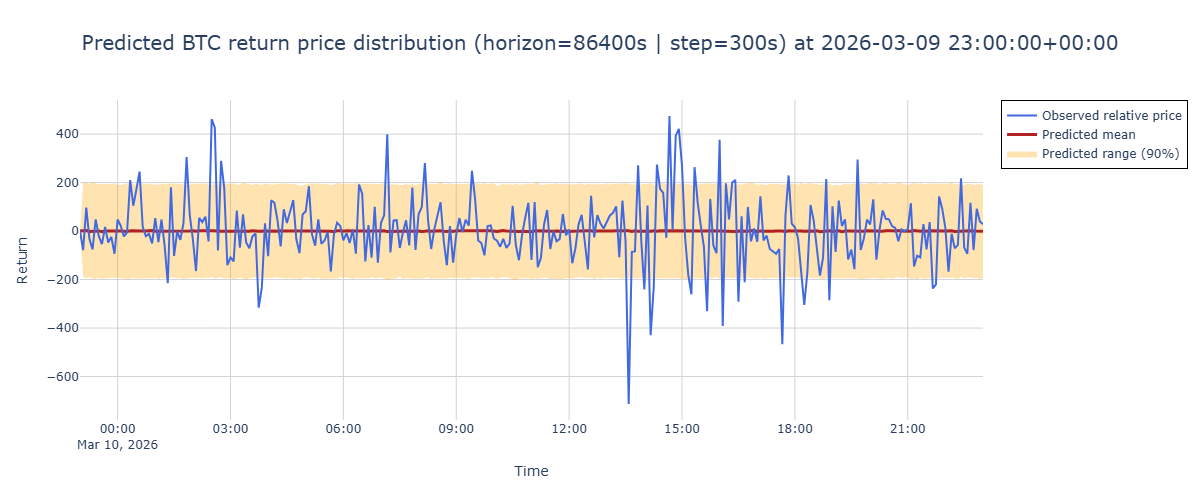

In [16]:
## Density forecast over returns (for the last asset and last prediction)
plot_quarantine(asset, predictions_evaluated[0], step=STEPS[0], prices=tracker_evaluator.tracker.prices, mode="direct")

Normalized CRPS score: 21.786324543975653


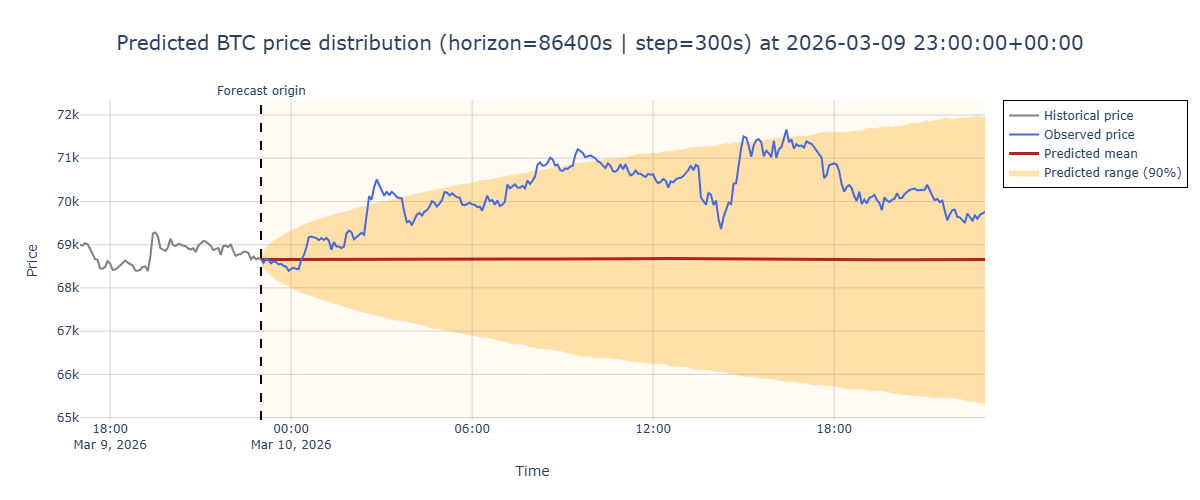

In [17]:
## Return forecast mapped into price space (for the last asset and last quarantine prediction)
print("Normalized CRPS score:", tracker_evaluator.scores[asset][-1][1])
plot_quarantine(asset, predictions_evaluated[0], step=STEPS[0], prices=tracker_evaluator.tracker.prices, mode="incremental", lookback_seconds=HORIZON/4)

# Tracker Comparison

This section compares the performance of different trackers.

- Lower CRPS indicates **better probabilistic forecasts**

In [18]:
from crunch_synth import load_all_results, plot_tracker_comparison

In [19]:
df_all = load_all_results(current_results_dir, horizon=HORIZON)
df_all

Directory: results\2026-03-05T00-00-00_to_2026-03-10T23-00-00\*h86400.json
[✔] Found 2 files:
   - GaussianStepTracker_h86400.json
   - LightGBMVolatilityTracker_h86400.json


,tracker,asset,horizon,ts,score,time
0,GaussianStepTracker,BTC,86400,1772668800,25.823718,2026-03-05 00:00:00+00:00
1,GaussianStepTracker,BTC,86400,1772672400,25.948617,2026-03-05 01:00:00+00:00
2,GaussianStepTracker,BTC,86400,1772676000,25.651746,2026-03-05 02:00:00+00:00
3,GaussianStepTracker,BTC,86400,1772679600,25.321846,2026-03-05 03:00:00+00:00
4,GaussianStepTracker,BTC,86400,1772683200,26.382773,2026-03-05 04:00:00+00:00
...,...,...,...,...,...,...
283,LightGBMVolatilityTracker,BTC,86400,1773169200,21.668356,2026-03-10 19:00:00+00:00
284,LightGBMVolatilityTracker,BTC,86400,1773172800,21.052278,2026-03-10 20:00:00+00:00
285,LightGBMVolatilityTracker,BTC,86400,1773176400,21.467482,2026-03-10 21:00:00+00:00
286,LightGBMVolatilityTracker,BTC,86400,1773180000,21.786066,2026-03-10 22:00:00+00:00


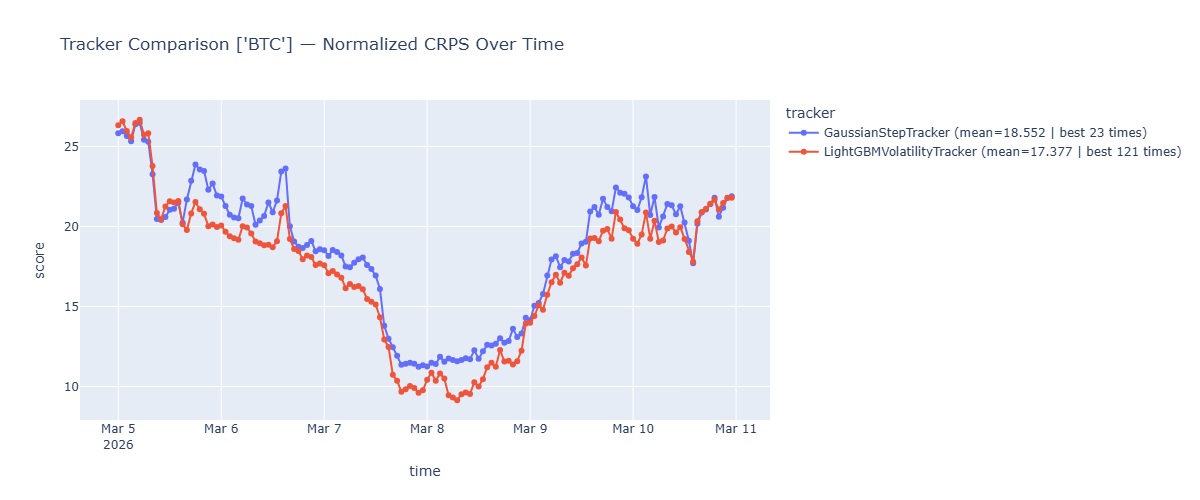

In [20]:
# Tracker comparison all assets (A lower CRPS score reflects more accurate predictions)
# Scores appear after quarantine: a score at time t evaluates a forecast issued at (t - horizon)
plot_tracker_comparison(df_all)

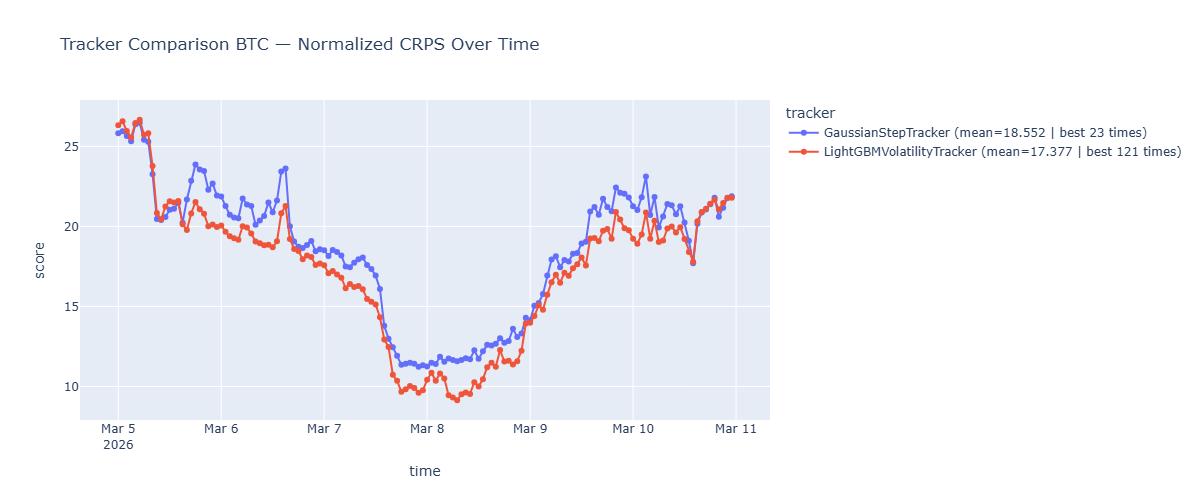

In [21]:
for asset in assets:
    plot_tracker_comparison(df_all, asset)

# Where to Experiment

You can improve the tracker by modifying:

### Feature engineering
`compute_feat()`

Ideas:
- rolling statistics
- volatility estimators
- momentum indicators
- regime detection

### Training data
`build_training_data()`

Ideas:
- different targets
- multi-horizon prediction
- alternative volatility measures

### Model
`train_model()`

Ideas:
- hyperparameter tuning
- different ML models
- ensemble models

### Forecast distribution
inside the tracker

Ideas:
- non-Gaussian distributions
- mixture models
- quantile forecasts

# Submit your Notebook

To submit your work, you must:
1. Download your Notebook from Colab
2. Optional: Download 'resources' directory (warm-start)
2. Upload it to the platform
3. Create a run to validate it

### >> https://hub.crunchdao.com/competitions/synth/submit/notebook

![Download and Submit Notebook](https://raw.githubusercontent.com/crunchdao/competitions/refs/heads/master/documentation/animations/download-and-submit-notebook.gif)